# Dataframer: --------'s Odyssey to Pandas DF

### [—————————————pipeline—————————————]
### »——raw—»—clean—»—normalize—»—DATAFRAME——»

Here are some transformation and frequencies for future exploratory analysis of Green's Odyssey.

Columns: author, year, title, book_num, text, num_lines, num_sentences, num_words, 


In [1]:
import numpy as np
import pandas as pd

import re
import nltk

import os

In [2]:
import sys
sys.path.append('/Users/debr/English-Homer') 
import matplotlib.pyplot as plt
import seaborn as sns
import bard_visualization as viz# This will apply the visualization settings

In [3]:
# TO UPDATE
translator = "AT_Murray" # Enter the translator's name

# Check Paths
filepath = f"/Users/debr/odysseys_en/Normalized_txts/Odyssey_{translator}_Normalized_v2.txt"
output_path = f"/Users/debr/English-Homer/dataframers_by_author/{translator}_DFed/"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
output_path_plots = f"{output_path}/plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)

# READING FILE TO extracted_lines
with open(filepath, 'r') as file:
    extracted_lines = file.readlines()

text = "".join(extracted_lines)

In [12]:
import re

def string_into_books(text, book_breaker):
    """
    Split a string into books/sections based on a pattern.
    
    Args:
        text (str): Text to process
        book_breaker (str): Pattern that indicates the start of a new book/section
    
    Returns:
        list: List of strings, where each string contains the content for one book/section
    """
    books = re.split(rf'{book_breaker}\s', text)
    # Remove the first element (it's empty or contains text before the first "Book")
    if books[0].strip() == "": 
        books = books[1:] #
        print(len(books))
    else:
        print("Warning: There was text before the first 'Book'")
    return books

def list_into_books(lines_list, book_breaker):
    
    """
    Split a list of strings into books/sections based on a pattern,
    excluding the lines that contain the book_breaker pattern.
    
    Args:
        lines_list (list): List of strings to process
        book_breaker (str): Pattern that indicates the start of a new book/section
    
    Returns:
        list: List of lists, where each inner list contains lines for one book/section
    """
    books = []
    current_book = []
    
    for line in lines_list:
        if line.strip().startswith(book_breaker):
            # If we already have content in current_book, save it and start a new one
            if current_book:
                books.append(current_book)
                current_book = []
            
            # Don't add the book_breaker line to the new book
            # Just start a new empty book
        else:
            # Add the line to the current book
            current_book.append(line)
    
    # Don't forget to add the last book if there's content
    if current_book:
        books.append(current_book)
    
    return books

# Example usage:
book_breaker = "Scroll"

#books = string_into_books(text, book_breaker)
books = list_into_books(extracted_lines, book_breaker)

# Verify the results
print(f"Found {len(books)} books")
for i, book in enumerate(books):
    print(f"Book {i+1} starts with: {book[0]}")
    print(f"Book {i+1} has {len(book)} lines")

Found 24 books
Book 1 starts with: Tell me, O Muse, of that many-sided hero who

Book 1 has 284 lines
Book 2 starts with: Now when the child of morning, rosy-fingered

Book 2 has 288 lines
Book 3 starts with: But as the sun was rising from the fair sea into

Book 3 has 325 lines
Book 4 starts with: They reached the low lying city of Lacedaemon , where they drove straight to the

Book 4 has 538 lines
Book 5 starts with: And now, as Dawn rose from her couch beside

Book 5 has 310 lines
Book 6 starts with: So here Odysseus slept, overcome by sleep and

Book 6 has 233 lines
Book 7 starts with: Thus, then, did Odysseus wait and pray; but the

Book 7 has 224 lines
Book 8 starts with: Now when the child of morning, rosy-fingered

Book 8 has 382 lines
Book 9 starts with:  And Odysseus answered, "King Alkinoos, it is a

Book 9 has 372 lines
Book 10 starts with:  Thence we went on to the Aeolian island where

Book 10 has 376 lines
Book 11 starts with: Then, when we had got down to the sea shore 

In [13]:
import pandas as pd
import re

def odyssey_dataframer(author, year, title, list_books):
    """
    Splits a list_books into rows and creates a DataFrame.
    Args:
    list_books (list): The full text of the Odyssey
    author (str): Author name
    year (str): Publication year
    title (str): Book title
    Returns:
    pd.DataFrame: DataFrame with columns for author, year, title, book_num, and text
    """
    # Create a list to store the data for each book
    data = []
    
    # Loop through each book in the list
    for i, book_text in enumerate(list_books, 1):  # Start counting from 1
        # Add a row for this book
        data.append({
            'author': author,
            'year': year,
            'title': title,
            'book_num': i,
            'text': book_text
        })
    
    # Create the DataFrame from the data
    df = pd.DataFrame(data)
    
    return df


df = odyssey_dataframer(f"{translator}", "1919", "The Odyssey", books)
df

,author,year,title,book_num,text
0,AT_Murray,1919,The Odyssey,1,"[Tell me, O Muse, of that many-sided hero who\..."
1,AT_Murray,1919,The Odyssey,2,"[Now when the child of morning, rosy-fingered\..."
2,AT_Murray,1919,The Odyssey,3,[But as the sun was rising from the fair sea i...
3,AT_Murray,1919,The Odyssey,4,[They reached the low lying city of Lacedaemon...
4,AT_Murray,1919,The Odyssey,5,"[And now, as Dawn rose from her couch beside\n..."
5,AT_Murray,1919,The Odyssey,6,"[So here Odysseus slept, overcome by sleep and..."
6,AT_Murray,1919,The Odyssey,7,"[Thus, then, did Odysseus wait and pray; but t..."
7,AT_Murray,1919,The Odyssey,8,"[Now when the child of morning, rosy-fingered\..."
8,AT_Murray,1919,The Odyssey,9,"[ And Odysseus answered, ""King Alkinoos, it is..."
9,AT_Murray,1919,The Odyssey,10,[ Thence we went on to the Aeolian island wher...


In [14]:
import pandas as pd
import re

# Functions to count lines, sentences, and words
def count_lines(text):
    """Function to count lines in a text by the number of newline characters.

    Args:
        text (list or str): The text as a list of lines or a string.

    Returns:
        int: The number of lines in the text.
    """
    if isinstance(text, list):
        return len(text)  # Each element in the list is a line
    if isinstance(text, float) and pd.isna(text):
        return 0
    if not isinstance(text, str):
        return 0
    return text.count('\n') + 1

def count_sentences(text):
    """Function to count sentences in a text.

    Args:
        text (list or str): The text as a list of lines or a string.

    Returns:
        int: The number of sentences in the text.
    """
    if isinstance(text, list):
        text = " ".join(text)  # Convert list of lines into a single string
    if isinstance(text, float) and pd.isna(text):
        return 0
    if not isinstance(text, str):
        return 0
    return len(re.findall(r'[.!?]+', text))  # Count sentence endings

def count_words(text):
    """Count the number of words in a text.

    Args:
        text (list or str): The text as a list of lines or a string.

    Returns:
        int: The number of words in the text.
    """
    if isinstance(text, list):
        text = " ".join(text)  # Convert list of lines into a single string
    if isinstance(text, float) and pd.isna(text):
        return 0
    if not isinstance(text, str):
        return 0
    return len(re.findall(r'\b\w+\b', text))

# Apply functions & add new columns
df['num_lines'] = df['text'].apply(count_lines)
df['num_sentences'] = df['text'].apply(count_sentences)
df['num_words'] = df['text'].apply(count_words)
df

,author,year,title,book_num,text,num_lines,num_sentences,num_words
0,AT_Murray,1919,The Odyssey,1,"[Tell me, O Muse, of that many-sided hero who\...",284,131,4214
1,AT_Murray,1919,The Odyssey,2,"[Now when the child of morning, rosy-fingered\...",288,132,4262
2,AT_Murray,1919,The Odyssey,3,[But as the sun was rising from the fair sea i...,325,165,4766
3,AT_Murray,1919,The Odyssey,4,[They reached the low lying city of Lacedaemon...,538,279,8162
4,AT_Murray,1919,The Odyssey,5,"[And now, as Dawn rose from her couch beside\n...",310,149,4723
5,AT_Murray,1919,The Odyssey,6,"[So here Odysseus slept, overcome by sleep and...",233,112,3483
6,AT_Murray,1919,The Odyssey,7,"[Thus, then, did Odysseus wait and pray; but t...",224,99,3377
7,AT_Murray,1919,The Odyssey,8,"[Now when the child of morning, rosy-fingered\...",382,187,5690
8,AT_Murray,1919,The Odyssey,9,"[ And Odysseus answered, ""King Alkinoos, it is...",372,171,5882
9,AT_Murray,1919,The Odyssey,10,[ Thence we went on to the Aeolian island wher...,376,175,5748


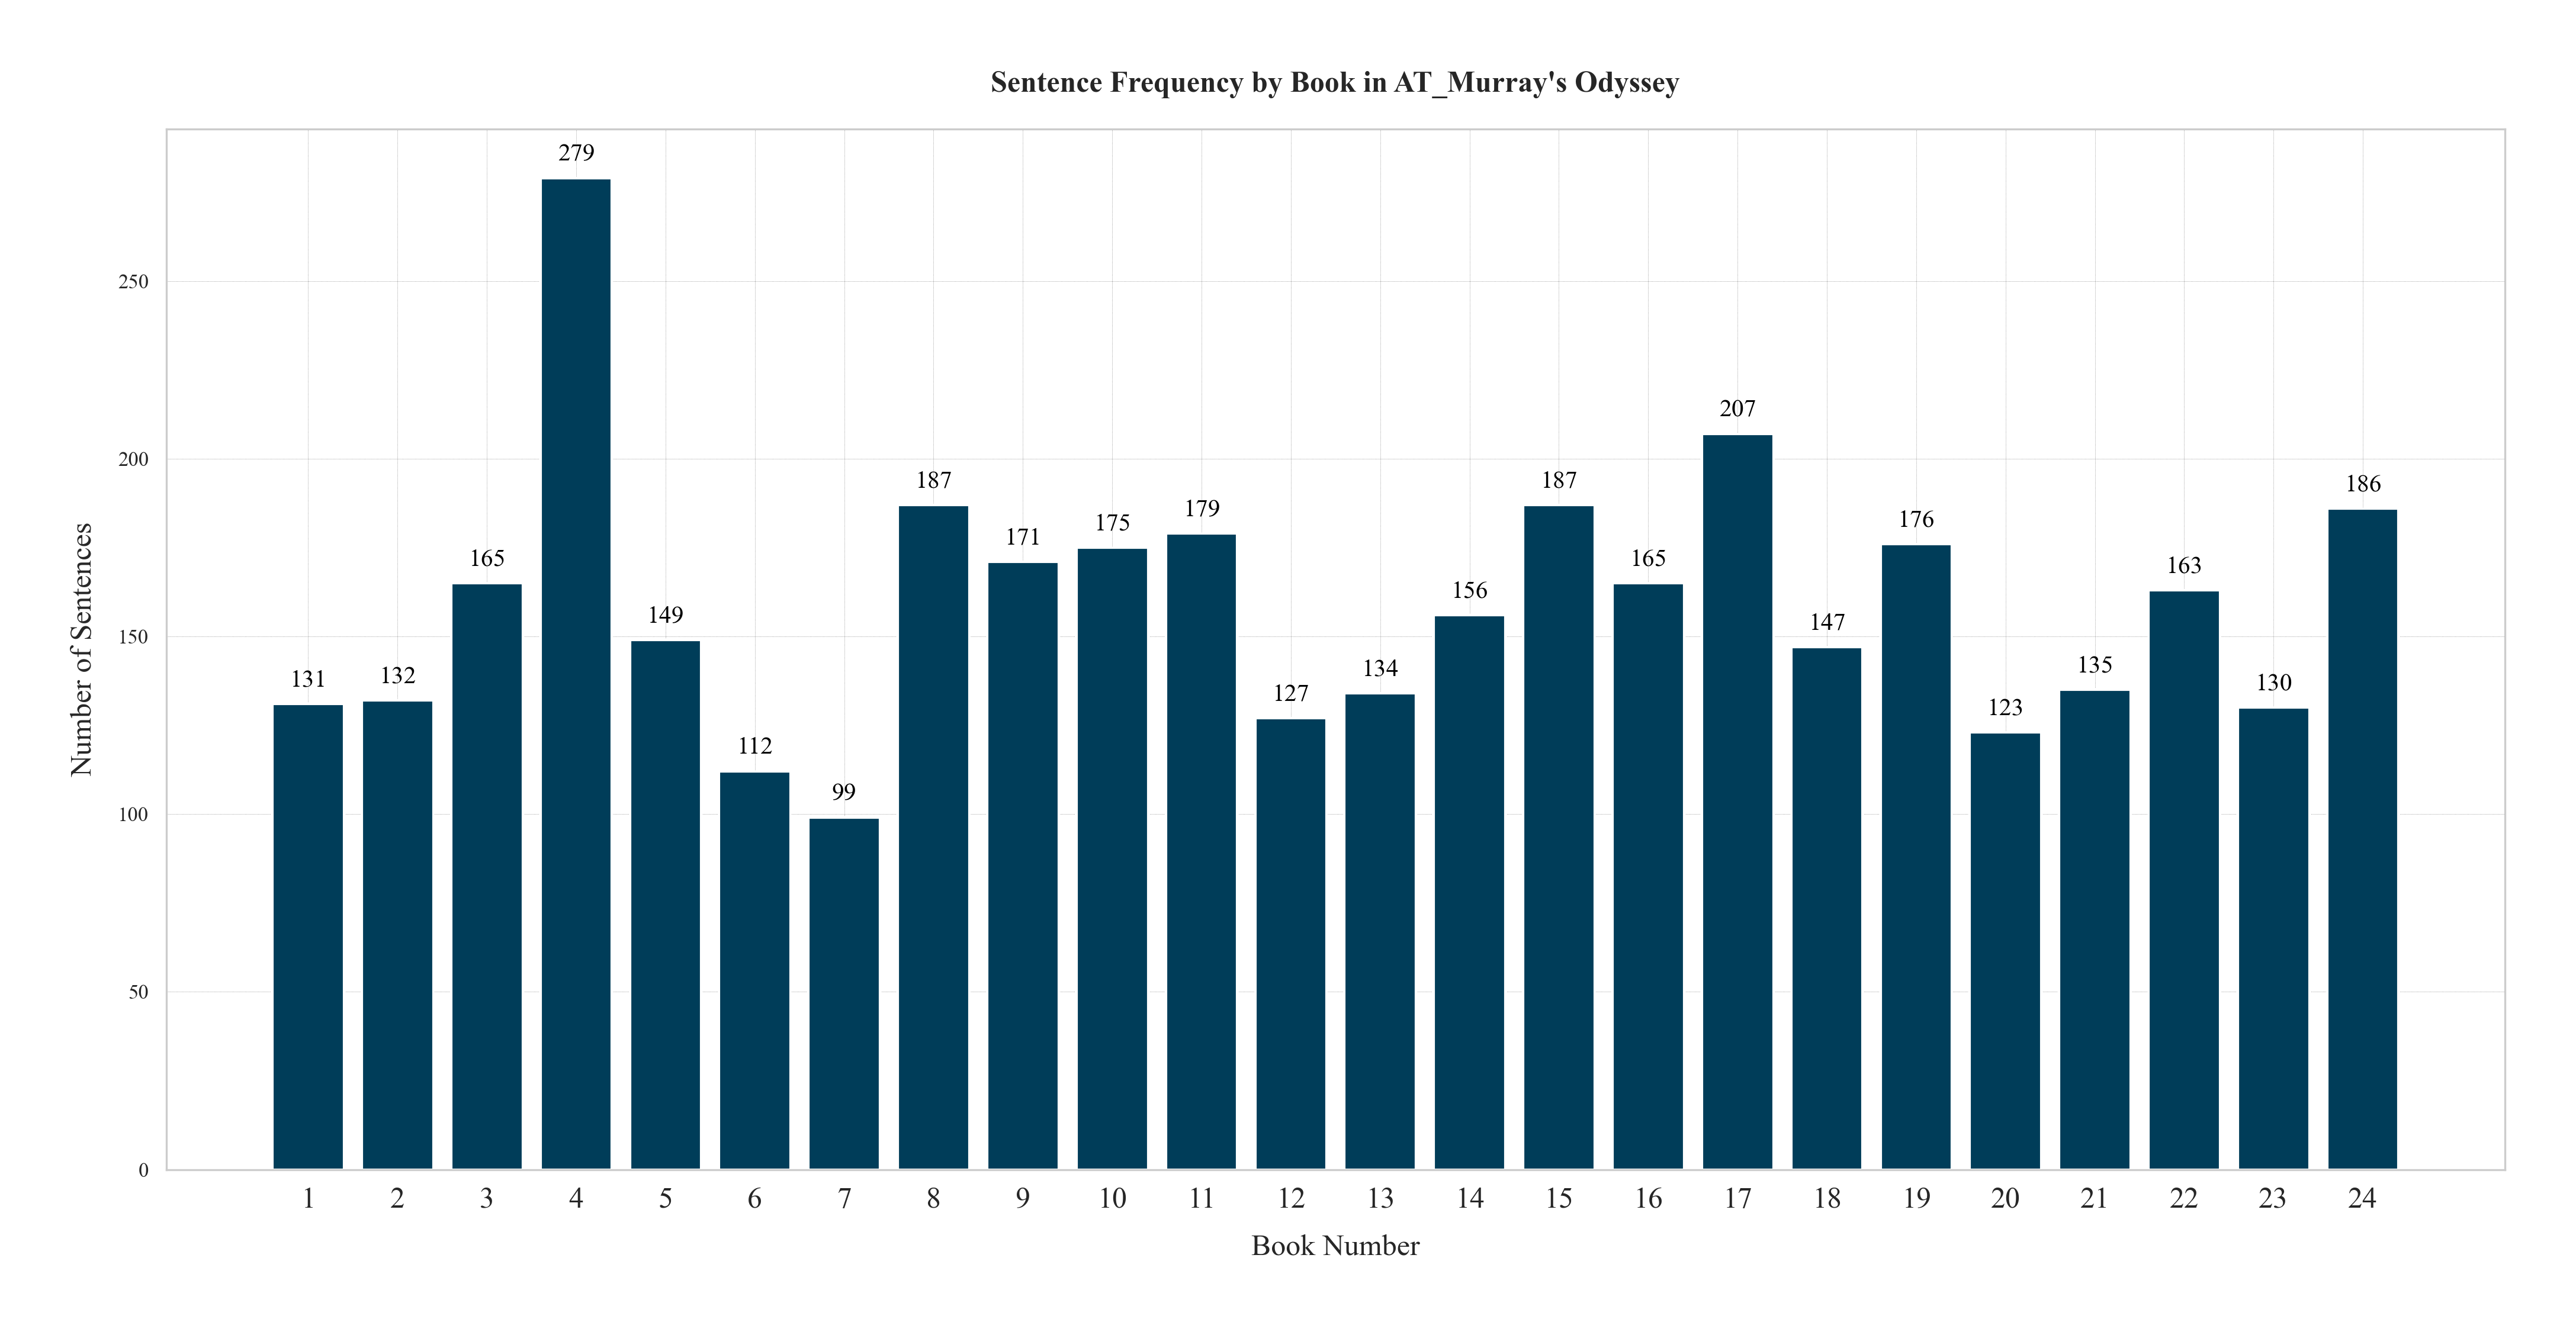

In [15]:
# Group by book_num and count the number of sentences in each book
sentences_per_book = df.groupby('book_num')['num_sentences'].sum()

# Create the plot using predefined styles
fig, ax = plt.subplots(figsize=(14, 7))

# Use predefined color cycle from viz.COLORS
ax.bar(sentences_per_book.index, sentences_per_book.values)  # Use 'orange'

ax.set_xlabel('Book Number')
ax.set_ylabel('Number of Sentences')
ax.set_title(f"Sentence Frequency by Book in {translator}'s Odyssey")

# Ensure all book numbers are shown on the x-axis
ax.set_xticks(sentences_per_book.index)

# Grid styling from viz
ax.grid(axis='y', alpha=0.5)
# Add values on top of bars
for i, v in enumerate(sentences_per_book.values):
    ax.text(i + 1, v + 5, str(v), ha='center', fontsize=10, color='black')

# Apply tight layout
plt.tight_layout()

# Save the figure using the predefined function
plt.savefig(f"{output_path_plots}/{translator}-sentence_freq.png")

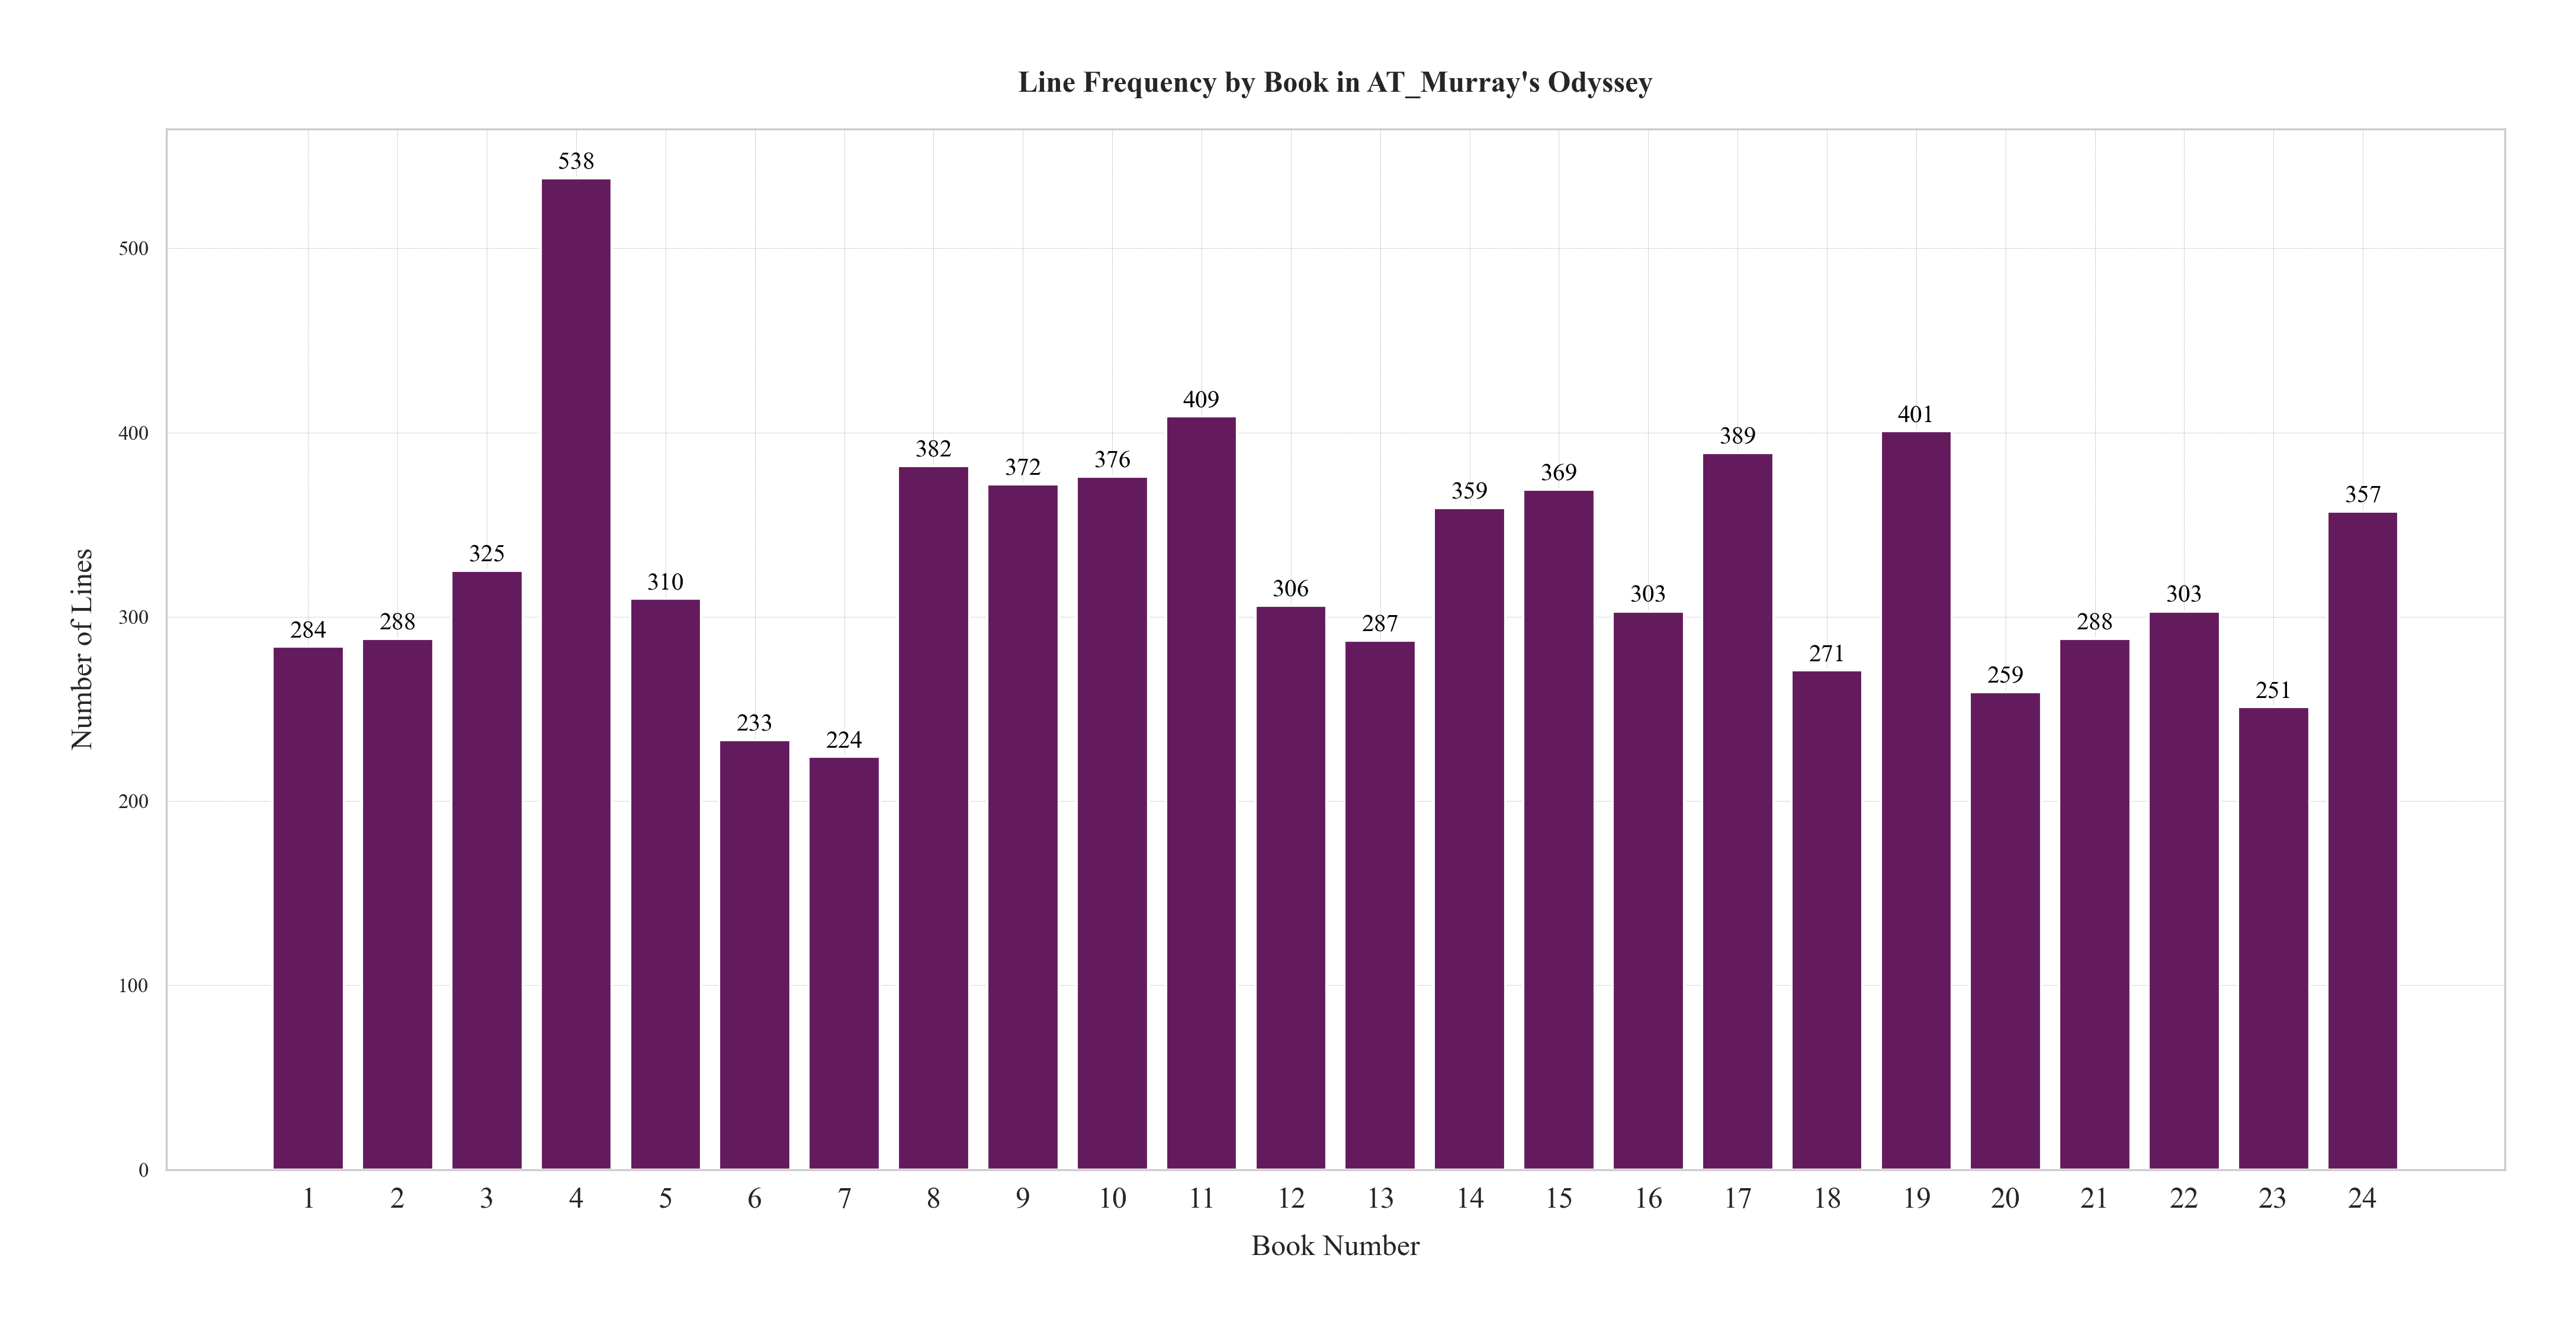

In [16]:
# Group by book_num and count the number of lines in each book
lines_per_book = df.groupby('book_num')['num_lines'].sum()

# Create the plot using predefined styles
fig, ax = plt.subplots(figsize=(14, 7))

# Use predefined color cycle from viz.COLORS
ax.bar(lines_per_book.index, lines_per_book.values, color='#641B5E')  # Use 'orange'

ax.set_xlabel('Book Number')
ax.set_ylabel('Number of Lines')
ax.set_title(f"Line Frequency by Book in {translator}'s Odyssey")

# Ensure all book numbers are shown on the x-axis
ax.set_xticks(lines_per_book.index)

# Grid styling from viz
ax.grid(axis='y', alpha=0.5)
# Add values on top of bars
for i, v in enumerate(lines_per_book.values):
    ax.text(i + 1, v + 5, str(v), ha='center', fontsize=10, color='black')

# Apply tight layout
plt.tight_layout()

# Save the figure using the predefined function
plt.savefig(f"{output_path_plots}/{translator}-lines_freq.png")

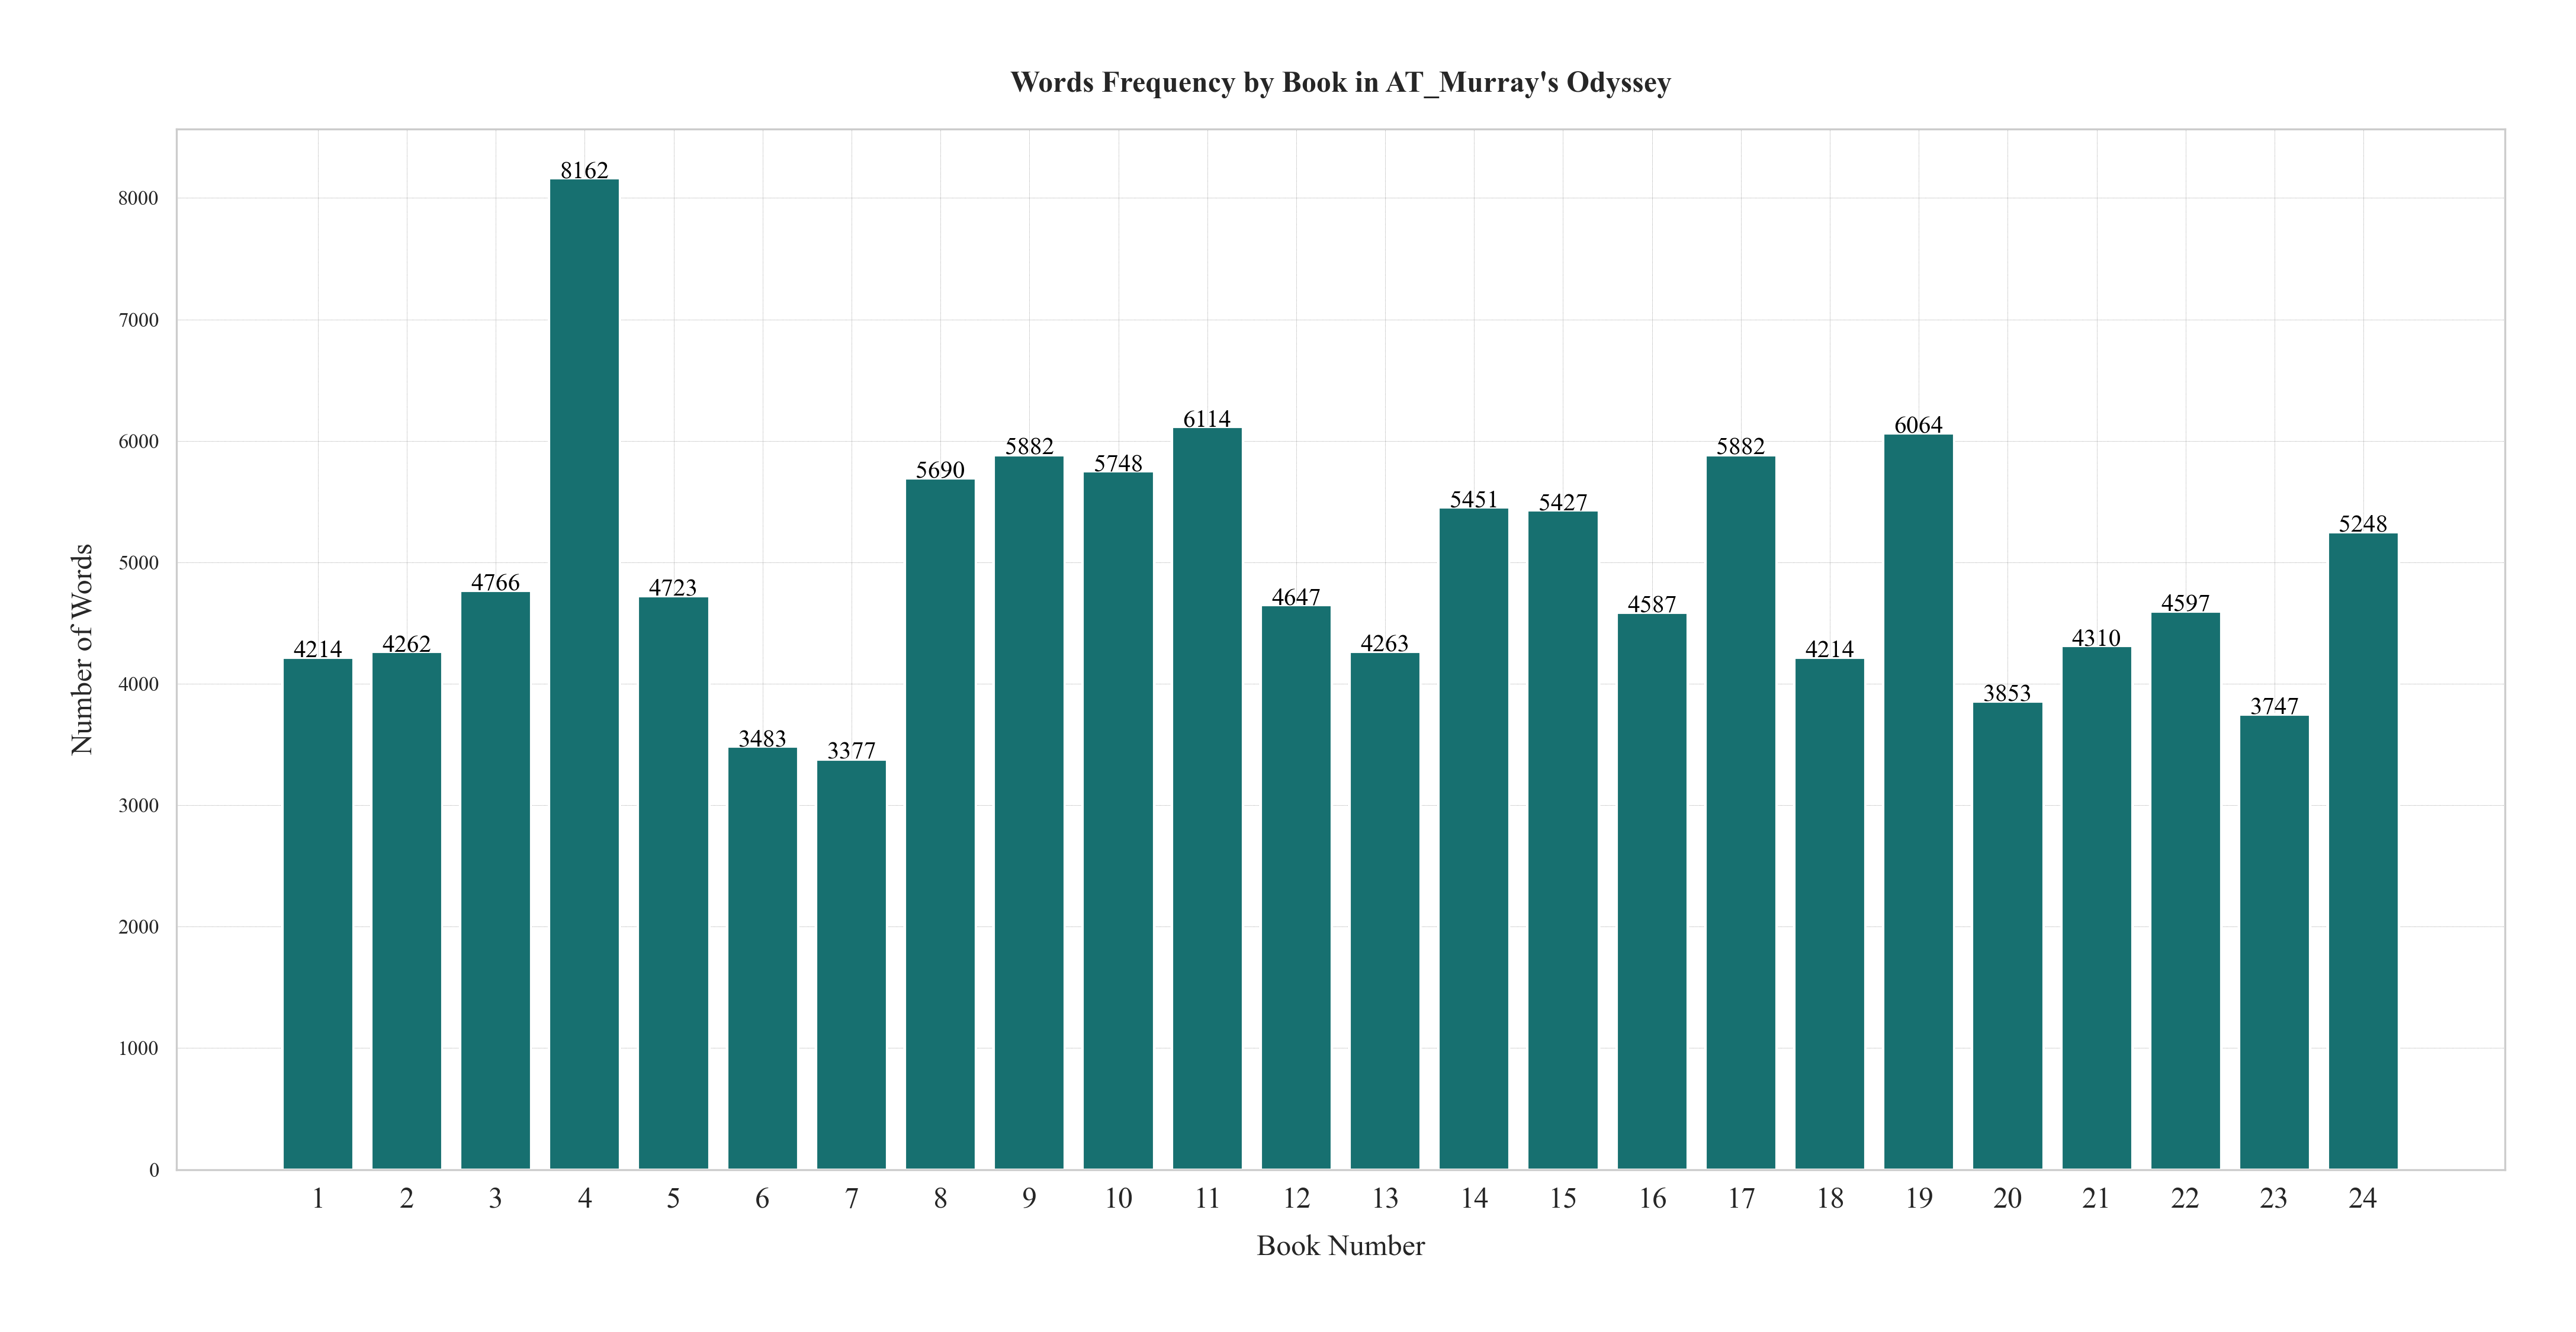

In [17]:
# Group by book_num and count the number of words in each book
words_per_book = df.groupby('book_num')['num_words'].sum()

# Create the plot using predefined styles
fig, ax = plt.subplots(figsize=(14, 7))

# Use predefined color cycle from viz.COLORS
ax.bar(words_per_book.index, words_per_book.values, color='#177070')  # Use 'orange'

ax.set_xlabel('Book Number')
ax.set_ylabel('Number of Words')
ax.set_title(f"Words Frequency by Book in {translator}'s Odyssey")

# Ensure all book numbers are shown on the x-axis
ax.set_xticks(words_per_book.index)

# Grid styling from viz
ax.grid(axis='y', alpha=0.5)
# Add values on top of bars
for i, v in enumerate(words_per_book.values):
    ax.text(i + 1, v + 5, str(v), ha='center', fontsize=10, color='black')

# Apply tight layout
plt.tight_layout()

# Save the figure using the predefined function
plt.savefig(f"{output_path_plots}/{translator}-words_freq_bB.png")

In [18]:
books_first_lines = {
    'Book 1': 'The man, Muse—tell me about that resourceful man, who wandered',
    'Book 2': 'When Dawn appeared, early risen and rosy-fingered,',
    'Book 3': "Deserting the deep’s enchanting surface, the sun rose up",
    'Book 4': 'Now they came to deep-hollowed Lakedaimon with its ravines',
    'Book 5': 'As Dawn arose from her bed beside illustrious Tithonos,',
    'Book 6': 'So Odysseus slept on there, godlike and much-enduring,',
    'Book 7': 'So while Odysseus prayed there, godlike and much-enduring,',
    'Book 8': 'When Dawn appeared, early risen and rosy-fingered,',
    'Book 9': 'Then resourceful Odysseus responded to him, saying:',
    'Book 10': '“To the isle of Aiolia then we came, where was the dwelling',
    'Book 11': '“But when we came down to the ship and the sea, first off',
    'Book 12': '“After our ship left the course of Ocean’s river and came',
    'Book 13': 'So he spoke: every one of them sat hushed and silent,',
    'Book 14': 'But the rough path up from the harbor was that which Odysseus',
    'Book 15': 'Now Pallas Athene was gone to spacious Lakedaimon,',
    'Book 16': 'The two in the hut, Odysseus and the noble swineherd,',
    'Book 17': 'When Dawn appeared, early risen and rosy-fingered,',
    'Book 18': 'Now there came up a public beggar, whose custom it was to beg',
    'Book 19': 'So noble Odysseus was left behind, there in the hall,',
    'Book 20': 'But noble Odysseus bedded down for sleep in the forecourt.',
    'Book 21': 'The goddess, grey-eyed Athene, now put it into the mind',
    'Book 22': 'Now resourceful Odysseus stripped himself of his rags',
    'Book 23': 'Chuckling, the old woman ascended to the upper chamber,',
    'Book 24': 'Hermes, god of Kyllene, now summoned forth the ghosts'
}

In [19]:
# Create output directory if it doesn't exist
output_filepath = f"/Users/debr/odysseys_en/Odyssey_dfs/Odyssey_{translator}_eda.csv"
os.makedirs(os.path.dirname(output_filepath), exist_ok=True)

# save df to csv
df.to_csv(output_filepath, index=False)

